Museum of Modern Art Collection
-- https://www.kaggle.com/datasets/momanyc/museum-collection/data

Análise e classificação de obras de arte do MoMA usando visão computacional

In [1]:
%pip install pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


02 - Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
df = pd.read_csv("data/moma/artworks.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130262 entries, 0 to 130261
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Artwork ID          130262 non-null  int64  
 1   Title               130200 non-null  str    
 2   Artist ID           128802 non-null  str    
 3   Name                128802 non-null  str    
 4   Date                127950 non-null  str    
 5   Medium              118343 non-null  str    
 6   Dimensions          118799 non-null  str    
 7   Acquisition Date    124799 non-null  str    
 8   Credit              127192 non-null  str    
 9   Catalogue           130262 non-null  str    
 10  Department          130262 non-null  str    
 11  Classification      130262 non-null  str    
 12  Object Number       130262 non-null  str    
 13  Diameter (cm)       1399 non-null    float64
 14  Circumference (cm)  10 non-null      float64
 15  Height (cm)         111893 non-null  float64


Trabalhando com Imgs

In [3]:
from PIL import Image

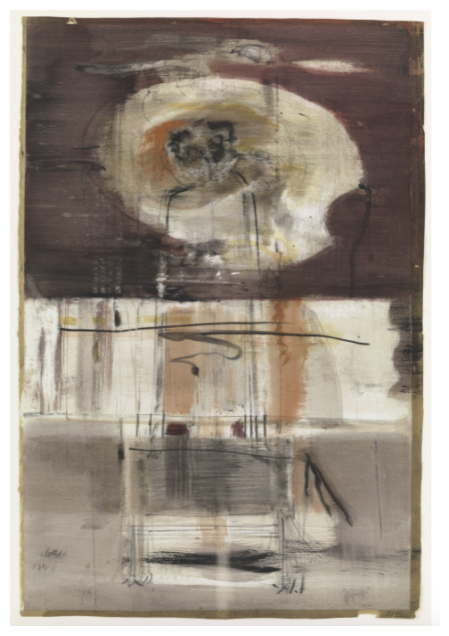

In [4]:
img = Image.open("img/img01.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()


In [5]:
img = img.resize((224, 224))

img_array = np.array(img)

media_rgb = img_array.mean(axis=(0,1))

print("RGB médio:", media_rgb)

RGB médio: [147.68299585 136.51393096 124.107103   255.        ]


Instalando o torch

In [7]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
from torchvision import models, transforms

In [7]:
model = models.resnet50(pretrained=True)
model.fc = torch.nn.Identity()
model.eval()

c:\Users\kaiog\Documents\11 - Git\01 - GitHub\04 - Web\who-is-the-artist\jupyter-notebook\.venv\Lib\site-packages\torchvision\models\_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kaiog\Documents\11 - Git\01 - GitHub\04 - Web\who-is-the-artist\jupyter-notebook\.venv\Lib\site-packages\torchvision\models\_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



In [30]:
print(df.columns.tolist())
print(df.shape)
print(df.head(3).to_string())

['Artwork ID', 'Title', 'Artist ID', 'Name', 'Date', 'Medium', 'Dimensions', 'Acquisition Date', 'Credit', 'Catalogue', 'Department', 'Classification', 'Object Number', 'Diameter (cm)', 'Circumference (cm)', 'Height (cm)', 'Length (cm)', 'Width (cm)', 'Depth (cm)', 'Weight (kg)', 'Duration (s)']
(130262, 21)
   Artwork ID                                                                                                          Title Artist ID                      Name  Date                                                          Medium                          Dimensions Acquisition Date                                                          Credit Catalogue             Department Classification Object Number  Diameter (cm)  Circumference (cm)  Height (cm)  Length (cm)  Width (cm)  Depth (cm)  Weight (kg)  Duration (s)
0           2                                      Ferdinandsbrücke Project, Vienna, Austria, Elevation, preliminary version      6210               Otto Wagner  1896  

In [ ]:
# Artista que queremos prever
y = df["Name"]

# Apenas colunas numéricas
X = df.select_dtypes(include=["number"]).drop(
    columns=["Artist ID"],
    errors="ignore"
)

# Substitui NaN pela mediana de cada coluna
X = X.fillna(X.median())

print(X.isna().sum())

Artwork ID            0
Diameter (cm)         0
Circumference (cm)    0
Height (cm)           0
Length (cm)           0
Width (cm)            0
Depth (cm)            0
Weight (kg)           0
Duration (s)          0
dtype: int64


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)

ValueError: Input contains NaN

In [40]:
import os

print(os.getcwd())
print(os.listdir("."))

c:\Users\kaiog\Documents\11 - Git\01 - GitHub\04 - Web\who-is-the-artist\jupyter-notebook
['.venv', 'data', 'img', 'moma.ipynb', 'moma02.ipynb']
